Load in data to analyse:

In [4]:
import pandas as pd
import numpy as np
import os
import plotly.express as px
import chromatin_tracing_python.image_processing_functions as ip
import chromatin_tracing_python.trace_analysis_functions as tr
import glob

file_list = glob.glob('dist_90_deg_360/*.csv')
traces = []
for i, file in enumerate(file_list):
    trace = pd.read_csv(file)
    trace.reset_index()
    trace.columns = ['frame','x','y','z','QC']
    trace['trace_ID'] = i
    trace['frame_name']=trace['frame']
    traces.append(trace)
traces = pd.concat(traces, axis=0).reset_index(drop=True)

In [27]:
traces

,frame,x,y,z,QC,trace_ID,frame_name
0,0,-0.392960,-7.048194,9.957746,1.0,0,0
1,1,2.899204,-5.231228,16.259380,1.0,0,1
2,2,-0.589529,8.293943,5.738483,1.0,0,2
3,3,-1.048072,4.613931,-0.482632,1.0,0,3
4,4,1.295295,1.604211,-0.370070,1.0,0,4
...,...,...,...,...,...,...,...
17995,85,-57.751418,-34.310625,-51.582655,1.0,199,85
17996,86,-55.027373,-41.995562,-41.671720,1.0,199,86
17997,87,-54.440127,-47.378151,-49.601855,1.0,199,87
17998,88,-60.132506,-46.446029,-54.691902,1.0,199,88


In [28]:
tr.plot_traces(traces,[50])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]


In [6]:
pwds = tr.pwd_calc(traces)

In [7]:
print('Number of traces in analysis: ', pwds.shape[0])
pwds_mean=np.clip(np.round(-np.nanmean(pwds, axis=0),0).astype(int),-800,0)

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Number of traces in analysis:  200


Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [12]:
pairs = tr.trace_analysis(traces, pwds)

In [13]:
pairs.sort_values(by=['aligned_mse'], ascending=True)

,idx1,idx2,aligned_mse,aligned_pcc,pwd_mse,pwd_pcc
373,1,176,46.300650,0.934979,49.746762,0.873503
2155,11,33,46.427309,0.938997,42.800404,0.738430
8120,46,48,47.809187,0.611888,65.021931,0.425488
1144,5,165,48.337045,0.891767,36.940044,0.931217
2429,12,120,49.974618,0.897750,67.921560,0.845968
...,...,...,...,...,...,...
19550,173,175,428.502265,-0.944453,74.046967,0.903604
5702,30,198,437.070556,-0.936608,65.932355,0.936706
15024,100,175,440.395888,-0.919133,83.246927,0.955605
5677,30,173,465.376254,-0.848800,37.564633,0.969805


In [14]:
px.histogram(pairs, x='aligned_mse')

We can visualize the aligned traces by their index in the pair matrix.

In [15]:
fig = tr.plot_aligned_traces(traces, [25,109,175])

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

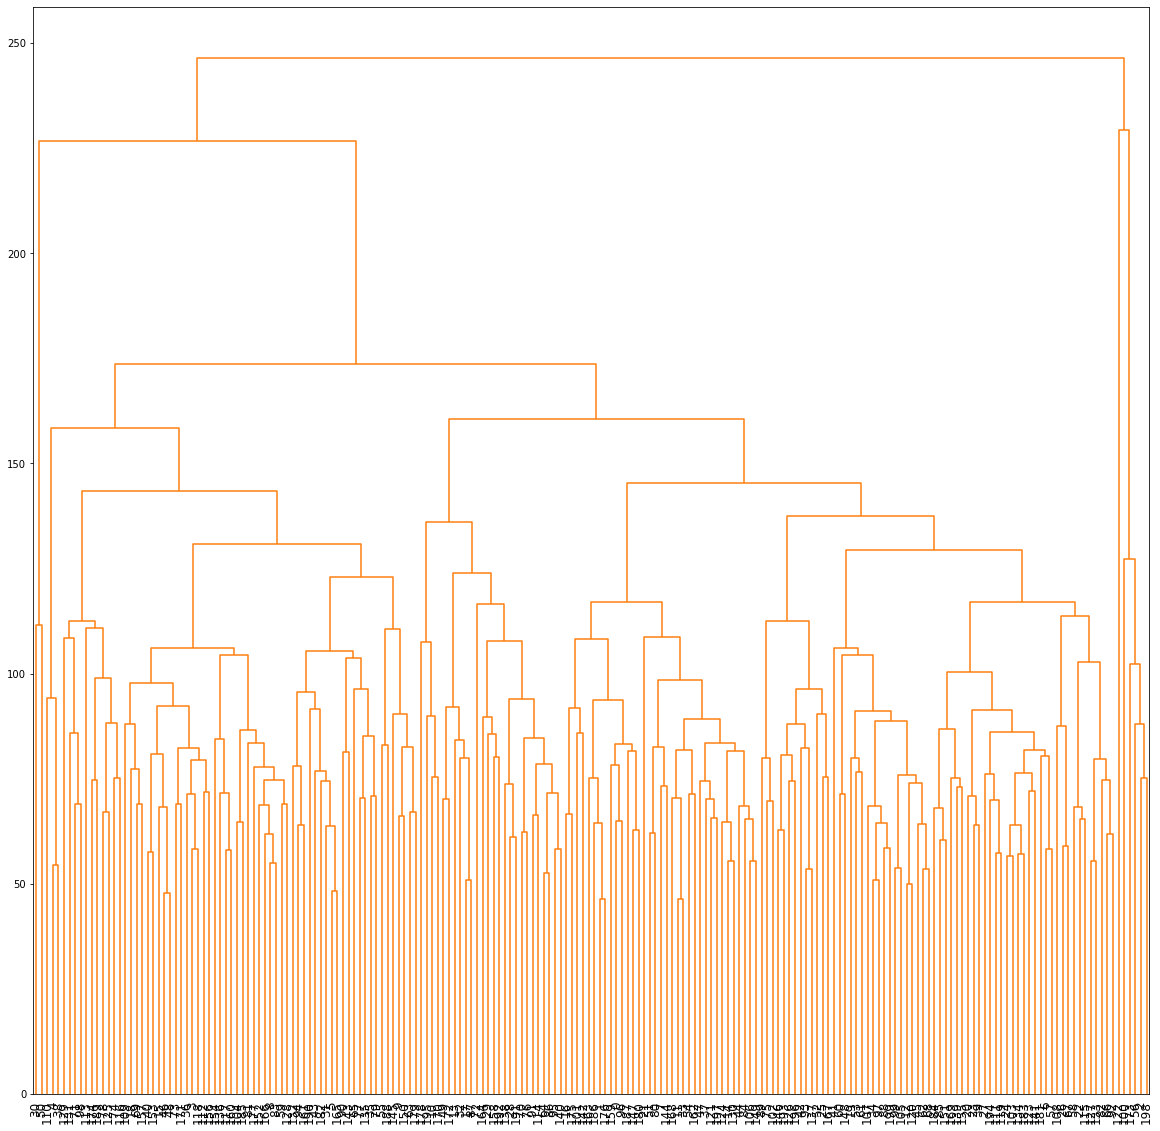

In [16]:
cluster_df = tr.trace_clustering(pairs, metric='aligned_mse', method='average', color_threshold=300)

In [17]:
cluster_id = 1
cluster_members = cluster_df[cluster_df['cluster']==cluster_id]['trace_ID'].values
print(cluster_members)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]


In [18]:
clust_aligned, clust_mean, clust_std = tr.general_procrustes_analysis(traces, cluster_members)
fig = tr.plot_gpa_output(clust_aligned, clust_mean, cluster_members)

Initial distance is 27846.574754157264
GPA converged after 8 cycles with distance 8154.123488070557
[0 1 2 3 4 5 6 7 8 9]


In [19]:
clust_std

array([[47.06175004, 60.56920224, 44.00524622,  0.        ],
       [36.51343821, 49.72852792, 35.7158025 ,  0.        ],
       [38.94273679, 45.04500944, 32.41408866,  0.        ],
       [40.48686689, 39.12499325, 35.64429892,  0.        ],
       [38.27907826, 36.42814712, 34.88726556,  0.        ],
       [36.75691817, 37.83528693, 35.18839476,  0.        ],
       [35.14582451, 38.57926543, 36.07285909,  0.        ],
       [34.93515871, 49.03078494, 40.75421592,  0.        ],
       [36.40621179, 48.92965199, 34.84318346,  0.        ],
       [47.57238177, 54.3478779 , 41.10427701,  0.        ]])

In [20]:
aligned_all_gpa=tr.run_gpa_all_clusters(traces, cluster_df, min_cluster=4)
fig = tr.plot_multi_points(aligned_all_gpa)

Initial distance is 30558.888031999602
GPA converged after 7 cycles with distance 8154.108681345294


In [21]:
clust_mean

array([[-107.40286847,  -14.27151053,  135.54753486,    1.        ],
       [-105.25103438,  -11.98706771,  114.37260638,    1.        ],
       [-111.21354914,   -3.46079023,   86.05326561,    1.        ],
       [-120.85668941,   23.76025432,   50.95512655,    1.        ],
       [-116.60477351,   58.98553677,   27.48038218,    1.        ],
       [-103.49840267,   93.63143182,   18.47119982,    1.        ],
       [ -73.52908406,  124.38915983,   17.24320085,    1.        ],
       [ -36.18591126,  145.80967285,   30.44443096,    1.        ],
       [  -7.80445313,  150.91305376,   38.90326236,    1.        ],
       [  15.49254323,  157.72847466,   48.5760348 ,    1.        ]])

In [24]:
tr.radius_of_gyration(clust_mean)

165.74076373363377

In [23]:
tr.elongation(clust_mean)

Eigenvalues are  [7731.46473    1380.05097297   45.15121803]


0.8215020023807575

In [16]:
all_trace_ids = list(traces['trace_ID'].unique())
px.bar(x=all_trace_ids, y = [tr.radius_of_gyration(points) for points in tr.points_from_traces(traces, all_trace_ids)])

In [17]:
px.bar(x=all_trace_ids, y=[tr.elongation(points) for points in tr.points_from_traces(traces, all_trace_ids)])

Eigenvalues are  [6297.6569678  2069.07088767  423.02233839]
Eigenvalues are  [40262.32656421  1830.34714025   590.62321085]
Eigenvalues are  [23069.48731059   970.17653838   614.35368921]
Eigenvalues are  [6764.50478127 3061.40249734 1694.47329008]
Eigenvalues are  [16210.11776589  6504.42815334   801.63981393]
Eigenvalues are  [4233.69743894 2491.01117051  838.96463964]
Eigenvalues are  [27192.01826357  2624.90912477  1364.21144352]
Eigenvalues are  [3533.27158491 2798.91916283 1684.12647552]
Eigenvalues are  [12016.52928951   853.79740592   488.14978733]
Eigenvalues are  [16215.33114981  1683.26392137  1023.8637511 ]
Eigenvalues are  [7280.62442446 1504.67732474  527.89379877]
Eigenvalues are  [14141.51338723  3486.79941024   575.63651051]
Eigenvalues are  [6126.3258035  2374.049228    273.00286154]
Eigenvalues are  [22918.80513366  3502.66217096   863.09135651]
Eigenvalues are  [6369.19422989 2102.00863331 1603.82297816]
Eigenvalues are  [6650.317142   3768.50633849 1337.11806871]


We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.